Further tidy up data from [Munch and Galizia 2016](https://www.nature.com/articles/srep21841): 
- multiple receptors go to the same glomerulus; 
- sometimes glomeruli cannot be distinguished experimentally. In this case, glomeruli are split, and the data is duplicated; 
- when there are multiple entries for the same glomeruli (due to the reasons above), max is taken, since the ORN would respond so long as one receptor is activated; 
- multiple InChIKey map to the same chemical name - this is taken care of by joining the chemical name with the InChIKey.  

The resulting dataframe has glomeruli in the rows, and chemicals in the columns. Note the sfr_SFR column denotes the 'spontaneous firing rate'. 

In [1]:
import pandas as pd

In [4]:
door_data = pd.read_csv(
    'data/DoOR/door_response_matrix.csv', index_col=0)
# receptors are in the columns, chemical descriptors in the rows
door_data

,ac1A,ac1B,ac2A,ac2B,ac3A,ac3B,ac4,Or1a,Or2a,Or7a,...,Ir75a,Ir75d,Ir76a,Ir84a,Ir92a,Ir64a.DC4,Ir64a.DP1m,ac1BC,ac2BC,Or83c
SFR,0.062714,0.069728,0.056050,0.070894,0.068650,0.044664,0.092695,0.000000,0.048452,0.025324,...,0.084396,0.026891,0.044802,0.174646,0.075637,0.000000,0.015990,0.020695,0.020457,0.078341
XLYOFNOQVPJJNP-UHFFFAOYSA-N,0.022637,NaN,0.086766,NaN,0.222510,0.061210,0.104771,0.024878,NaN,0.094439,...,0.304460,0.014351,0.033877,0.201460,0.000000,0.854963,0.180955,0.025222,0.022729,NaN
VHUUQVKOLVNVRT-UHFFFAOYSA-N,0.476843,NaN,0.049642,NaN,0.071876,0.378349,0.151007,NaN,0.056635,0.067536,...,0.121297,0.032358,0.057867,0.004327,0.016628,0.028357,0.021453,0.022958,0.024434,NaN
KIDHWZJUCRJVML-UHFFFAOYSA-N,0.060979,0.113309,0.883934,0.044309,0.189889,0.412169,0.092087,NaN,0.063791,0.050442,...,0.274430,0.026481,0.028581,0.162411,0.030773,0.326230,0.147709,0.025222,0.030685,NaN
VHRGRCVQAFMJIZ-UHFFFAOYSA-N,NaN,NaN,NaN,NaN,0.165465,0.062813,0.086691,NaN,0.051927,0.018918,...,0.196231,0.028839,0.034487,0.166272,0.039928,0.293186,0.101904,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
KJSVCIRMHUQNGQ-ADYYPQGGSA-N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
KWUWRILZYFCPRI-ADYYPQGGSA-N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
UQDUPQYQJKYHQI-UHFFFAOYSA-N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FLIACVVOZYBSBS-UHFFFAOYSA-N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<Axes: >

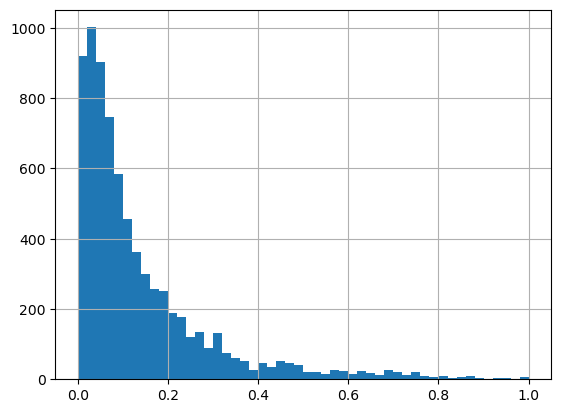

In [6]:
door_data.unstack().hist(bins = 50)

In [7]:
door_receptor_meta = pd.read_csv(
    'data/DoOR/door_receptor_mappings.csv', index_col=0)
# multiple receptors can go to the same glomerulus
# group together receptors that go to the same glomerulus later
receptor_to_glom = dict(
    zip(door_receptor_meta.receptor, door_receptor_meta.glomerulus))

door_receptor_meta

,receptor,sensillum,OSN,glomerulus,co.receptor,coexpressing,related1,related2,related3,related4,related5,related6,Ors,sensillum.type,adult,larva,dataset.existing,comment,code,code.OSN
1,?,?,?,VA7m,?,NaN,NaN,NaN,NaN,NaN,NaN,NaN,?,NaN,NaN,NaN,False,NaN,VA7m,NaN
2,Or42b,ab1,ab1A,DM1,Orco,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Or42b,antennal basiconic,True,True,True,NaN,DM1,ab1A
3,Or92a,ab1,ab1B,VA2,Orco,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Or92a,antennal basiconic,True,NaN,True,NaN,VA2,ab1B
4,Gr21a.Gr63a,ab1,ab1C,V,NaN,Gr21a+Gr63a,NaN,NaN,NaN,NaN,NaN,NaN,Gr21a+Gr63a,antennal basiconic,True,True,True,NaN,V,ab1C
5,Or10a,ab1,ab1D,DL1,Orco,Gr10a,Gr10a,NaN,NaN,NaN,NaN,NaN,Or10a+Gr10a,antennal basiconic,True,NaN,True,NaN,DL1,ab1D
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92,Or83a,NaN,NaN,NaN,Orco,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,True,True,NaN,NaN,NaN
93,Or83b,NaN,NaN,NaN,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,True,False,the Orco co-receptor expressed together with a...,NaN,NaN
94,Or85c,NaN,NaN,NaN,Orco,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,True,True,NaN,NaN,NaN
95,Or94a,NaN,NaN,NaN,Orco,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,True,True,NaN,NaN,NaN


In [8]:
chem_meta = pd.read_csv(
    'data/DoOR/door_chemical_meta.csv', index_col=0)
# similarly, the same chemical name can have multiple chemical keys
chem_meta.loc[:, ['name_inchi']] = chem_meta.Name + '_' + chem_meta.InChIKey
inchi_to_name_inchi = dict(zip(chem_meta.InChIKey, chem_meta.name_inchi))
chem_meta

,Class,Name,InChIKey,CID,CAS,Stensmyr.2003.WT,Schmuker.2007.TR,Dobritsa.2003.WT,Bruyne.2001.WT,Bruyne.2010.WT,Marshall.2010.WT,Hallem.2004.WT,name_inchi
1,NaN,sfr,SFR,SFR,SFR,NaN,1.0,NaN,1.0,0.0,0.000,NaN,sfr_SFR
2,other,water,XLYOFNOQVPJJNP-UHFFFAOYSA-N,962,7732-18-5,NaN,NaN,NaN,NaN,NaN,5.714,NaN,water_XLYOFNOQVPJJNP-UHFFFAOYSA-N
3,amine,ammonium hydroxide,VHUUQVKOLVNVRT-UHFFFAOYSA-N,14923,1336-21-6,NaN,NaN,NaN,NaN,NaN,2.714,NaN,ammonium hydroxide_VHUUQVKOLVNVRT-UHFFFAOYSA-N
4,amine,putrescine,KIDHWZJUCRJVML-UHFFFAOYSA-N,1045,110-60-1,NaN,0.0,NaN,NaN,NaN,5.667,NaN,putrescine_KIDHWZJUCRJVML-UHFFFAOYSA-N
5,amine,cadaverine,VHRGRCVQAFMJIZ-UHFFFAOYSA-N,273,462-94-2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,cadaverine_VHRGRCVQAFMJIZ-UHFFFAOYSA-N
...,...,...,...,...,...,...,...,...,...,...,...,...,...
689,NaN,"(Z,Z)-7,11-octacosadiene",KJSVCIRMHUQNGQ-ADYYPQGGSA-N,14464905,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"(Z,Z)-7,11-octacosadiene_KJSVCIRMHUQNGQ-ADYYPQ..."
690,NaN,"(Z,Z)-7,11-nonacosadiene",KWUWRILZYFCPRI-ADYYPQGGSA-N,14367348,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"(Z,Z)-7,11-nonacosadiene_KWUWRILZYFCPRI-ADYYPQ..."
691,NaN,methyl laurate,UQDUPQYQJKYHQI-UHFFFAOYSA-N,8139,111-82-0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,methyl laurate_UQDUPQYQJKYHQI-UHFFFAOYSA-N
692,NaN,methyl palmitate,FLIACVVOZYBSBS-UHFFFAOYSA-N,8181,112-39-0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,methyl palmitate_FLIACVVOZYBSBS-UHFFFAOYSA-N


In [9]:
# if there is glomerulus information, is it larva, adult or nan?
door_receptor_meta[~door_receptor_meta.glomerulus.isna()][['adult', 'larva']].value_counts(dropna=False)

adult  larva
True   NaN      47
NaN    NaN      19
True   True     13
Name: count, dtype: int64

In [10]:
# first get receptors in the adult
# get all receptors mapped to a glomerulus
adult_door_data = door_data.loc[:, door_data.columns.isin(
    door_receptor_meta.receptor[~door_receptor_meta.glomerulus.isna()])]
adult_door_data.columns = adult_door_data.columns.map(receptor_to_glom)
adult_door_data.index = adult_door_data.index.map(inchi_to_name_inchi)
# glomeruli into columns
adult_door_data = adult_door_data.T
adult_door_data.reset_index(names='glomerulus', inplace=True)

# tidying up
adult_door_data.fillna(0, inplace=True)
adult_door_data = adult_door_data[adult_door_data.glomerulus != '?']

# tidy up: duplicate data in DM5+DM3 into 2 rows
adult_door_data = pd.concat([adult_door_data,
                             adult_door_data[adult_door_data.glomerulus == 'DM5+DM3']], ignore_index=True)
adult_door_data.glomerulus[adult_door_data.glomerulus ==
                           'DM5+DM3'] = ['DM5', 'DM3']
# duplicate data in DL2d/v into 2 rows
adult_door_data = pd.concat([adult_door_data,
                             adult_door_data[adult_door_data.glomerulus == 'DL2d/v']], ignore_index=True)
adult_door_data.glomerulus[adult_door_data.glomerulus ==
                           'DL2d/v'] = ['DL2d', 'DL2v']
# duplicate data in VL1+DP1l+VC5 into 3 rows
adult_door_data = pd.concat([adult_door_data,
                             adult_door_data[adult_door_data.glomerulus ==
                                             'VL1+DP1l+VC5'],
                             adult_door_data[adult_door_data.glomerulus == 'VL1+DP1l+VC5']], ignore_index=True)
adult_door_data.glomerulus[adult_door_data.glomerulus ==
                           'VL1+DP1l+VC5'] = ['VL1', 'VC5', 'DP1l']
# duplicate data in VL1+VM1+VL2p into 3 rows
adult_door_data = pd.concat([adult_door_data,
                             adult_door_data[adult_door_data.glomerulus ==
                                             'VL1+VM1+VL2p'],
                             adult_door_data[adult_door_data.glomerulus == 'VL1+VM1+VL2p']], ignore_index=True)
adult_door_data.glomerulus[adult_door_data.glomerulus ==
                           'VL1+VM1+VL2p'] = ['VL1', 'VL2p', 'VM1']
# duplicate data in DL2d/v+VC3 into 3 rows
adult_door_data = pd.concat([adult_door_data,
                             adult_door_data[adult_door_data.glomerulus ==
                                             'DL2d/v+VC3'],
                             adult_door_data[adult_door_data.glomerulus == 'DL2d/v+VC3']], ignore_index=True)
adult_door_data.glomerulus[adult_door_data.glomerulus ==
                           'DL2d/v+VC3'] = ['DL2d', 'VC3', 'DL2v']

# then take the *maximum* receptor response per glomerulus for each chemical
# since either receptor being activated would result in that ORN being activated
adult_door_data = adult_door_data.groupby('glomerulus').max()
adult_door_data

C:\Users\44745\AppData\Local\Temp\ipykernel_8888\3529069885.py:18: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  adult_door_data.glomerulus[adult_door_data.glomerulus ==
C:\Users\44745\AppData\Local\Temp\ipykernel_8888\3529069885.py:18: Sett

,sfr_SFR,water_XLYOFNOQVPJJNP-UHFFFAOYSA-N,ammonium hydroxide_VHUUQVKOLVNVRT-UHFFFAOYSA-N,putrescine_KIDHWZJUCRJVML-UHFFFAOYSA-N,cadaverine_VHRGRCVQAFMJIZ-UHFFFAOYSA-N,ammonia_QGZKDVFQNNGYKY-UHFFFAOYSA-N,ethanolamine_HZAXFHJVJLSVMW-UHFFFAOYSA-N,heptylamine_WJYIASZWHGOTOU-UHFFFAOYSA-N,isoamylamine_BMFVGAAISNGQNM-UHFFFAOYSA-N,dimethylamine_ROSDSFDQCJNGOL-UHFFFAOYSA-N,...,(Z)-7-tricosene_IRYCVIRCWSSJOW-SQFISAMPSA-N,(Z)-9-tricosene_IGOWHGRNPLFNDJ-ZPHPHTNESA-N,(Z)-7-pentacosene_RORWYUWDGGVNRJ-SQFISAMPSA-N,"(Z,Z)-7,11-pentacosadiene_PJVWXEURPGIPNW-ADYYPQGGSA-N","(Z,Z)-7,11-heptacosadiene_RJYQFYALHBHYMG-ADYYPQGGSA-N","(Z,Z)-7,11-octacosadiene_KJSVCIRMHUQNGQ-ADYYPQGGSA-N","(Z,Z)-7,11-nonacosadiene_KWUWRILZYFCPRI-ADYYPQGGSA-N",methyl laurate_UQDUPQYQJKYHQI-UHFFFAOYSA-N,methyl palmitate_FLIACVVOZYBSBS-UHFFFAOYSA-N,palmitoleic acid_SECPZKHBENQXJG-FPLPWBNLSA-N
glomerulus,,,,,,,,,,,,,,,,,,,,,
D,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
DA1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
DA2,0.064859,0.017059,0.000000,0.306816,0.025091,0.305932,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
DA3,0.019317,0.000000,0.015024,0.015024,0.004293,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
DA4l,0.095284,0.000000,0.090697,0.032186,0.048279,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
DA4m,0.048452,0.000000,0.056635,0.063791,0.051927,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
DC1,0.100069,0.000000,0.097216,0.080654,0.085971,0.000000,0.000000,0.037799,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
DC2,0.079803,0.197693,0.123406,0.153453,0.000000,0.118779,0.128289,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
DC3,0.078341,0.000000,0.000000,0.000000,0.000000,0.170507,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


When the value here is 0, I think it should be ~interpreted as "this glomerulus is not active" (which seems to be the case in [Munch and Galizia 2016](https://www.nature.com/articles/srep21841). However it is probably possible that the experimental studies this is based on didn't always record from all glomeruli.

In [11]:
adult_door_data.to_csv('data/DoOR/processed_door_adult.csv')

In [ ]:
# sometimes presentation of an odour depresses an ORN 
# let's subtract that for convenience in models which can't take negative values 
# which means that there will be negative values 
adult_door_data.iloc[:,1:] = adult_door_data.iloc[:,1:].sub(adult_door_data.sfr_SFR, axis = 0)
adult_door_data.drop('sfr_SFR', axis = 1, inplace = True)
adult_door_data.to_csv('data/DoOR/processed_door_adult_sfr_subtracted.csv')
adult_door_data

,water_XLYOFNOQVPJJNP-UHFFFAOYSA-N,ammonium hydroxide_VHUUQVKOLVNVRT-UHFFFAOYSA-N,putrescine_KIDHWZJUCRJVML-UHFFFAOYSA-N,cadaverine_VHRGRCVQAFMJIZ-UHFFFAOYSA-N,ammonia_QGZKDVFQNNGYKY-UHFFFAOYSA-N,ethanolamine_HZAXFHJVJLSVMW-UHFFFAOYSA-N,heptylamine_WJYIASZWHGOTOU-UHFFFAOYSA-N,isoamylamine_BMFVGAAISNGQNM-UHFFFAOYSA-N,dimethylamine_ROSDSFDQCJNGOL-UHFFFAOYSA-N,gamma-butyrolactone_YEJRWHAVMIAJKC-UHFFFAOYSA-N,...,(Z)-7-tricosene_IRYCVIRCWSSJOW-SQFISAMPSA-N,(Z)-9-tricosene_IGOWHGRNPLFNDJ-ZPHPHTNESA-N,(Z)-7-pentacosene_RORWYUWDGGVNRJ-SQFISAMPSA-N,"(Z,Z)-7,11-pentacosadiene_PJVWXEURPGIPNW-ADYYPQGGSA-N","(Z,Z)-7,11-heptacosadiene_RJYQFYALHBHYMG-ADYYPQGGSA-N","(Z,Z)-7,11-octacosadiene_KJSVCIRMHUQNGQ-ADYYPQGGSA-N","(Z,Z)-7,11-nonacosadiene_KWUWRILZYFCPRI-ADYYPQGGSA-N",methyl laurate_UQDUPQYQJKYHQI-UHFFFAOYSA-N,methyl palmitate_FLIACVVOZYBSBS-UHFFFAOYSA-N,palmitoleic acid_SECPZKHBENQXJG-FPLPWBNLSA-N
glomerulus,,,,,,,,,,,,,,,,,,,,,
D,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
DA1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
DA2,-0.047800,-0.064859,0.241957,-0.039769,0.241072,-0.064859,-0.064859,-0.064859,-0.064859,-0.064859,...,-0.064859,-0.064859,-0.064859,-0.064859,-0.064859,-0.064859,-0.064859,-0.064859,-0.064859,-0.064859
DA3,-0.019317,-0.004293,-0.004293,-0.015024,-0.019317,-0.019317,-0.019317,-0.019317,-0.019317,0.008585,...,-0.019317,-0.019317,-0.019317,-0.019317,-0.019317,-0.019317,-0.019317,-0.019317,-0.019317,-0.019317
DA4l,-0.095284,-0.004587,-0.063098,-0.047006,-0.095284,-0.095284,-0.095284,-0.095284,-0.095284,-0.051603,...,-0.095284,-0.095284,-0.095284,-0.095284,-0.095284,-0.095284,-0.095284,-0.095284,-0.095284,-0.095284
DA4m,-0.048452,0.008183,0.015340,0.003475,-0.048452,-0.048452,-0.048452,-0.048452,-0.048452,0.022617,...,-0.048452,-0.048452,-0.048452,-0.048452,-0.048452,-0.048452,-0.048452,-0.048452,-0.048452,-0.048452
DC1,-0.100069,-0.002853,-0.019414,-0.014098,-0.100069,-0.100069,-0.062270,-0.100069,-0.100069,-0.017047,...,-0.100069,-0.100069,-0.100069,-0.100069,-0.100069,-0.100069,-0.100069,-0.100069,-0.100069,-0.100069
DC2,0.117890,0.043603,0.073650,-0.079803,0.038975,0.048485,-0.079803,-0.079803,-0.079803,-0.079803,...,-0.079803,-0.079803,-0.079803,-0.079803,-0.079803,-0.079803,-0.079803,-0.079803,-0.079803,-0.079803
DC3,-0.078341,-0.078341,-0.078341,-0.078341,0.092166,-0.078341,-0.078341,-0.078341,-0.078341,-0.078341,...,-0.078341,-0.078341,-0.078341,-0.078341,-0.078341,-0.078341,-0.078341,-0.078341,-0.078341,-0.078341
